In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

print("🎯 ДЗ: СЕГМЕНТАЦИЯ ИЗОБРАЖЕНИЙ - РАЗРАСТАНИЕ РЕГИОНОВ И WATERSHED")
print("=" * 70)
print("✅ Библиотеки загружены!")

🎯 ДЗ: СЕГМЕНТАЦИЯ ИЗОБРАЖЕНИЙ - РАЗРАСТАНИЕ РЕГИОНОВ И WATERSHED
✅ Библиотеки загружены!


# 🎯 ДЗ: СЕГМЕНТАЦИЯ ИЗОБРАЖЕНИЙ - РАЗРАСТАНИЕ РЕГИОНОВ И WATERSHED

## 1. 📷 ЗАГРУЗКА ИЗОБРАЖЕНИЯ И ПРЕДОБРАБОТКА

✅ Изображение sar_1.jpg успешно загружено!
   Размер: (300, 400, 3)


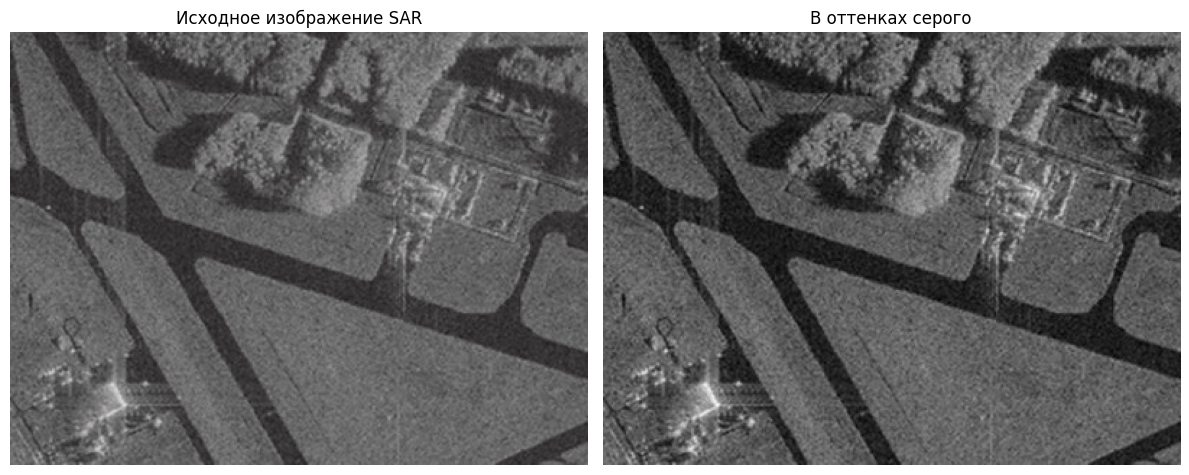

In [2]:
# Загрузка изображения для разрастания регионов
image_sar = cv2.imread('sar_1.jpg')
if image_sar is None:
    print("❌ ОШИБКА: Файл 'sar_1.jpg' не найден!")
    exit()

image_sar_gray = cv2.cvtColor(image_sar, cv2.COLOR_BGR2GRAY)
image_sar_rgb = cv2.cvtColor(image_sar, cv2.COLOR_BGR2RGB)

print("✅ Изображение sar_1.jpg успешно загружено!")
print(f"   Размер: {image_sar.shape}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_sar_rgb)
plt.title('Исходное изображение SAR')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_sar_gray, cmap='gray')
plt.title('В оттенках серого')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. 🌱 АЛГОРИТМ РАЗРАСТАНИЯ РЕГИОНОВ

In [3]:
def homo_average(img, mask, point, T):
    """Критерий однородности на основе среднего значения"""
    if np.count_nonzero(mask > 0) == 0:
        return False
    av_val = img[mask > 0].sum() / np.count_nonzero(mask > 0)

    if abs(av_val - img[point]) <= T:
        return True
    return False

def homo_variance(img, mask, point, T):
    """Критерий однородности на основе дисперсии"""
    if np.count_nonzero(mask > 0) == 0:
        return False

    region_pixels = img[mask > 0]
    mean_val = np.mean(region_pixels)
    variance = np.var(region_pixels)

    # Проверяем, попадает ли пиксель в диапазон mean ± sqrt(variance)
    if abs(img[point] - mean_val) <= max(math.sqrt(variance), T):
        return True
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    """Алгоритм разрастания регионов"""
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1

    print(f"   Начальная точка: {seed_point}")
    print(f"   Параметры: радиус={r}, порог={T}")

    iteration = 0
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)

        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i, j] == 0 and mask[i - r:i + r + 1, j - r:j + r + 1].sum() > 0:
                    if homo_fun(image, mask, (i, j), T):
                        local_mask[i, j] = 1

        count = np.count_nonzero(local_mask)
        if iteration < 10:  # Показываем только первые 10 итераций
            print(f"   Итерация {iteration + 1}: добавлено {count} пикселей")
        elif iteration == 10:
            print("   ... (продолжение вывода скрыто)")

        mask += local_mask
        iteration += 1

    print(f"✅ Алгоритм завершен за {iteration} итераций")
    return mask * 255

print("✅ Функции алгоритма разрастания регионов определены!")

✅ Функции алгоритма разрастания регионов определены!


## 3. 🎯 ПОДБОР ПАРАМЕТРОВ ДЛЯ ВЫДЕЛЕНИЯ ГАЗОНА

🔹 ТЕСТ 1: Базовые параметры (r=1, T=10)
   Начальная точка: (250, 250)
   Параметры: радиус=1, порог=10
   Итерация 1: добавлено 8 пикселей
   Итерация 2: добавлено 13 пикселей
   Итерация 3: добавлено 12 пикселей
   Итерация 4: добавлено 17 пикселей
   Итерация 5: добавлено 23 пикселей
   Итерация 6: добавлено 42 пикселей
   Итерация 7: добавлено 61 пикселей
   Итерация 8: добавлено 55 пикселей
   Итерация 9: добавлено 52 пикселей
   Итерация 10: добавлено 54 пикселей
   ... (продолжение вывода скрыто)
✅ Алгоритм завершен за 152 итераций

🔹 ТЕСТ 2: Увеличенный радиус и порог (r=3, T=25)
   Начальная точка: (250, 250)
   Параметры: радиус=3, порог=25
   Итерация 1: добавлено 48 пикселей
   Итерация 2: добавлено 119 пикселей
   Итерация 3: добавлено 192 пикселей
   Итерация 4: добавлено 264 пикселей
   Итерация 5: добавлено 331 пикселей
   Итерация 6: добавлено 401 пикселей
   Итерация 7: добавлено 478 пикселей
   Итерация 8: добавлено 550 пикселей
   Итерация 9: добавлено 620 пикселей


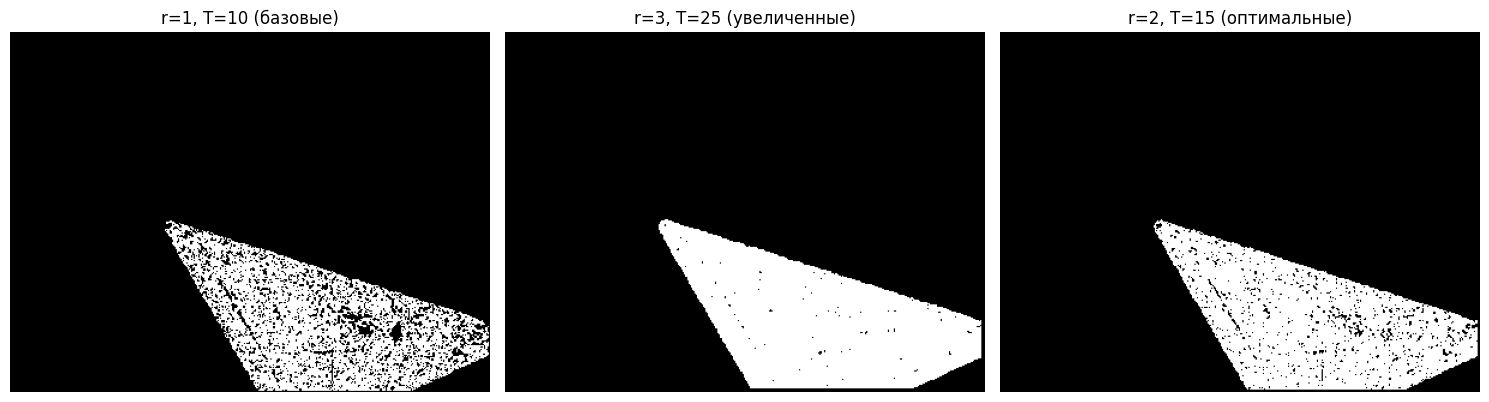

In [4]:
# Начальная точка в области газона
seed_point = (250, 250)

print("🔹 ТЕСТ 1: Базовые параметры (r=1, T=10)")
mask1 = region_growing(image_sar_gray, seed_point, homo_average, 1, 10)

print("\n🔹 ТЕСТ 2: Увеличенный радиус и порог (r=3, T=25)")
mask2 = region_growing(image_sar_gray, seed_point, homo_average, 3, 25)

print("\n🔹 ТЕСТ 3: Оптимальные параметры для газона (r=2, T=15)")
mask3 = region_growing(image_sar_gray, seed_point, homo_average, 2, 15)

# Визуализация результатов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask1, cmap='gray')
plt.title('r=1, T=10 (базовые)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask2, cmap='gray')
plt.title('r=3, T=25 (увеличенные)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask3, cmap='gray')
plt.title('r=2, T=15 (оптимальные)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 4. 🔍 СРАВНЕНИЕ КРИТЕРИЕВ ОДНОРОДНОСТИ

🔹 КРИТЕРИЙ НА ОСНОВЕ СРЕДНЕГО ЗНАЧЕНИЯ
   Начальная точка: (250, 250)
   Параметры: радиус=2, порог=15
   Итерация 1: добавлено 22 пикселей
   Итерация 2: добавлено 47 пикселей
   Итерация 3: добавлено 83 пикселей
   Итерация 4: добавлено 113 пикселей
   Итерация 5: добавлено 138 пикселей
   Итерация 6: добавлено 166 пикселей
   Итерация 7: добавлено 196 пикселей
   Итерация 8: добавлено 224 пикселей
   Итерация 9: добавлено 252 пикселей
   Итерация 10: добавлено 291 пикселей
   ... (продолжение вывода скрыто)
✅ Алгоритм завершен за 75 итераций

🔹 КРИТЕРИЙ НА ОСНОВЕ ДИСПЕРСИИ
   Начальная точка: (250, 250)
   Параметры: радиус=2, порог=15
   Итерация 1: добавлено 22 пикселей
   Итерация 2: добавлено 47 пикселей
   Итерация 3: добавлено 83 пикселей
   Итерация 4: добавлено 113 пикселей
   Итерация 5: добавлено 138 пикселей
   Итерация 6: добавлено 166 пикселей
   Итерация 7: добавлено 196 пикселей
   Итерация 8: добавлено 224 пикселей
   Итерация 9: добавлено 252 пикселей
   Итерация 10

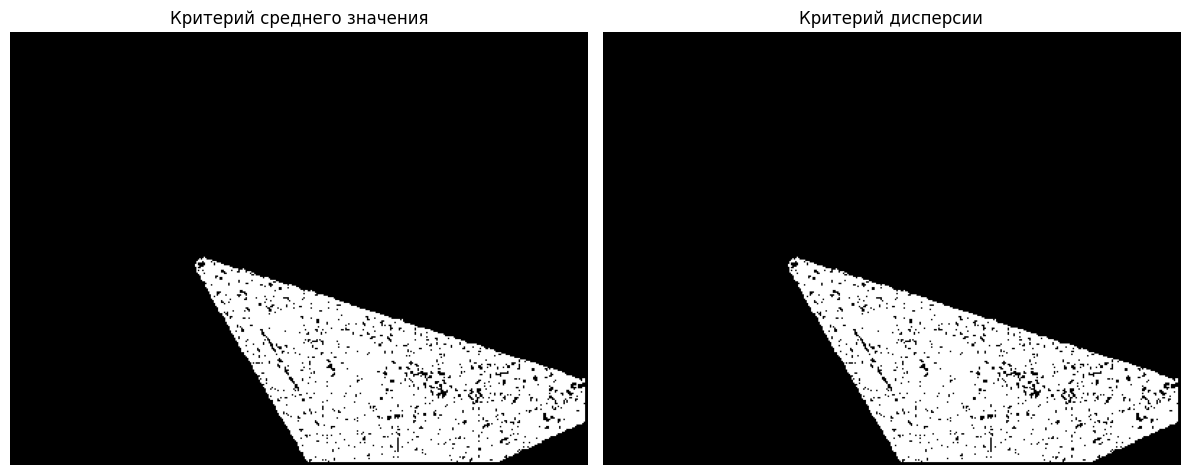

In [5]:
print("🔹 КРИТЕРИЙ НА ОСНОВЕ СРЕДНЕГО ЗНАЧЕНИЯ")
mask_avg = region_growing(image_sar_gray, seed_point, homo_average, 2, 15)

print("\n🔹 КРИТЕРИЙ НА ОСНОВЕ ДИСПЕРСИИ")
mask_var = region_growing(image_sar_gray, seed_point, homo_variance, 2, 15)

# Визуализация сравнения критериев
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mask_avg, cmap='gray')
plt.title('Критерий среднего значения')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_var, cmap='gray')
plt.title('Критерий дисперсии')
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. 🎨 K-MEANS СЕГМЕНТАЦИЯ

✅ K-means с k=2 завершен
✅ K-means с k=3 завершен
✅ K-means с k=5 завершен


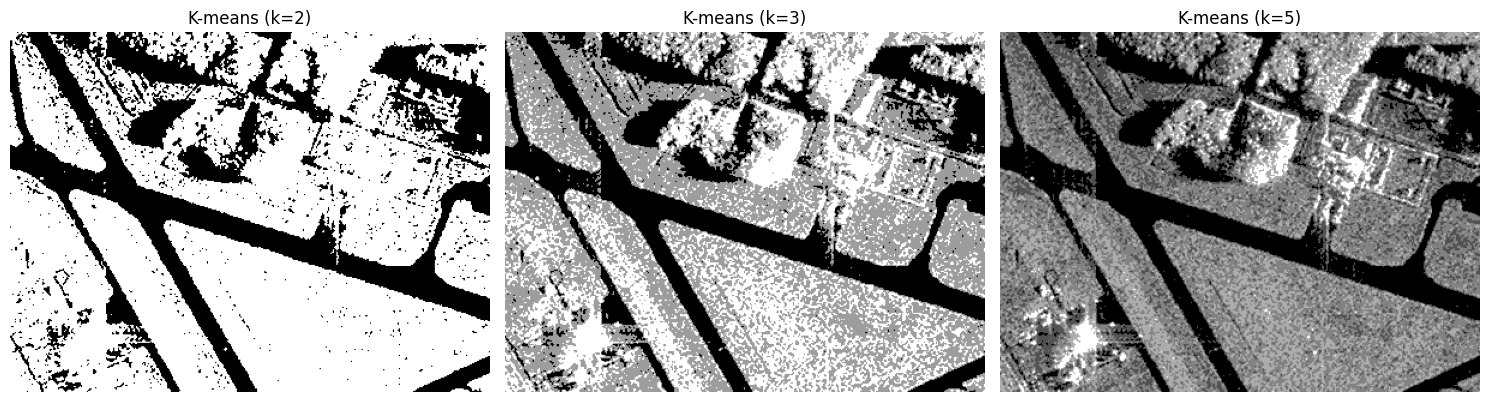

In [6]:
# Подготовка данных для k-means
z = image_sar_gray.reshape((-1, 1))
z = np.float32(z)

# Параметры для k-means
k_values = [2, 3, 5]
criteria_list = [
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 7, 0.5),
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.3),
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.2)
]

plt.figure(figsize=(15, 5))

for i, (k, criteria) in enumerate(zip(k_values, criteria_list)):
    ret, label, center = cv2.kmeans(z, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    center = np.uint8(center)
    res = center[label.flatten()]
    res2 = res.reshape(image_sar_gray.shape)

    plt.subplot(1, 3, i + 1)
    plt.imshow(res2, cmap='gray')
    plt.title(f'K-means (k={k})')
    plt.axis('off')

    print(f"✅ K-means с k={k} завершен")

plt.tight_layout()
plt.show()

## 6. 🌴 СЕГМЕНТАЦИЯ PALM ДЕРЕВЬЕВ МЕТОДОМ WATERSHED

✅ Изображение palm_1.jpg успешно загружено!
   Размер: (527, 535, 3)


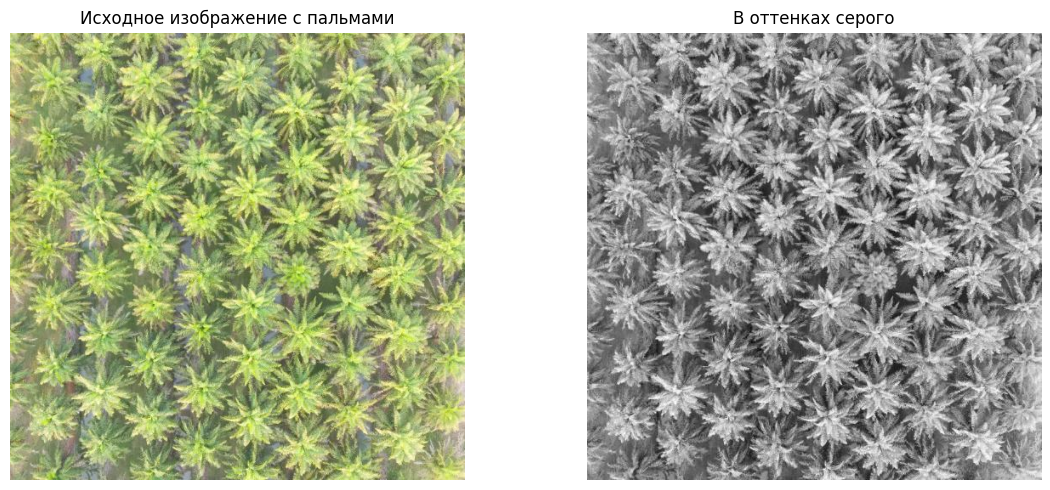

In [7]:
# Загрузка изображения с пальмами
image_palm = cv2.imread('palm_1.jpg')
if image_palm is None:
    print("❌ ОШИБКА: Файл 'palm_1.jpg' не найден!")
    exit()

image_palm_gray = cv2.cvtColor(image_palm, cv2.COLOR_BGR2GRAY)
image_palm_rgb = cv2.cvtColor(image_palm, cv2.COLOR_BGR2RGB)

print("✅ Изображение palm_1.jpg успешно загружено!")
print(f"   Размер: {image_palm.shape}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_palm_rgb)
plt.title('Исходное изображение с пальмами')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_palm_gray, cmap='gray')
plt.title('В оттенках серого')
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. 🔧 ПРЕДОБРАБОТКА ДЛЯ WATERSHED

🔹 ПРИМЕНЕНИЕ БИЛАТЕРАЛЬНОГО ФИЛЬТРА
🔹 БИНАРИЗАЦИЯ МЕТОДОМ ОТСУ
🔹 ВЫЧИСЛЕНИЕ DISTANCE TRANSFORM


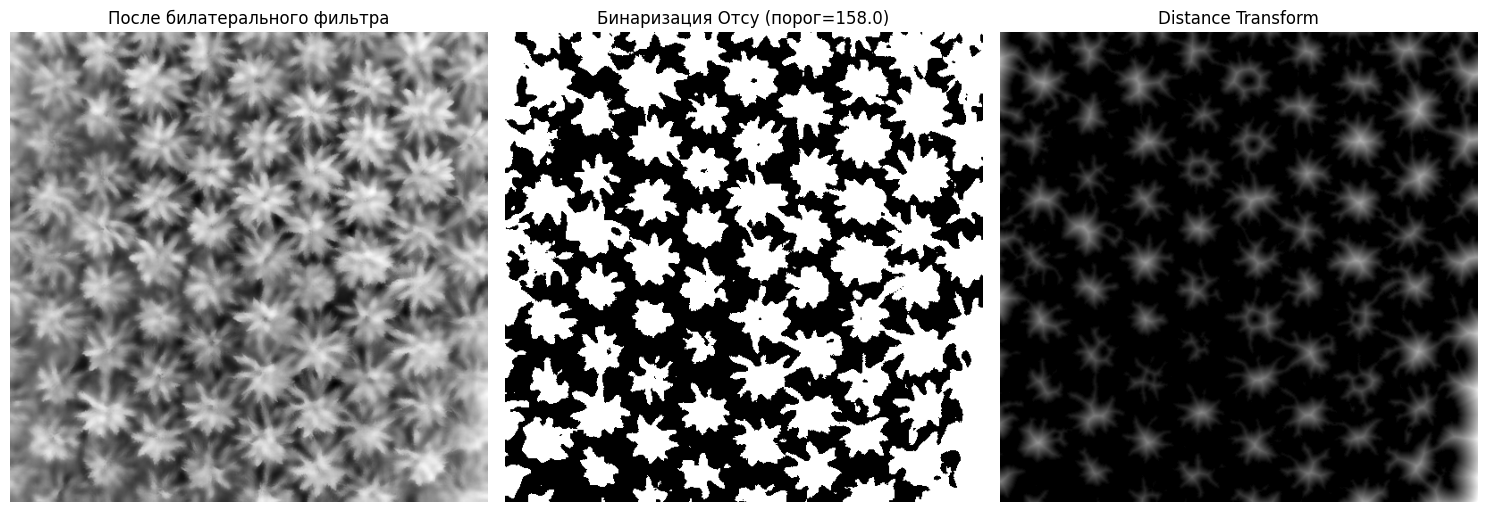

In [8]:
# Применение билатерального фильтра для сохранения границ
print("🔹 ПРИМЕНЕНИЕ БИЛАТЕРАЛЬНОГО ФИЛЬТРА")
palm_gb = cv2.bilateralFilter(image_palm_gray, d=11, sigmaColor=75, sigmaSpace=75)

# Бинаризация методом Отсу
print("🔹 БИНАРИЗАЦИЯ МЕТОДОМ ОТСУ")
ret, thresh = cv2.threshold(palm_gb, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(palm_gb, cmap='gray')
plt.title('После билатерального фильтра')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title(f'Бинаризация Отсу (порог={ret:.1f})')
plt.axis('off')

# Distance Transform
print("🔹 ВЫЧИСЛЕНИЕ DISTANCE TRANSFORM")
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)

plt.subplot(1, 3, 3)
plt.imshow(dist, cmap='gray')
plt.title('Distance Transform')
plt.axis('off')

plt.tight_layout()
plt.show()

## 8. 📐 WATERSHED СЕГМЕНТАЦИЯ

🔹 ОПРЕДЕЛЕНИЕ ПЕРЕДНЕГО ПЛАНА
🔹 ПРИМЕНЕНИЕ ALGORITHMA WATERSHED


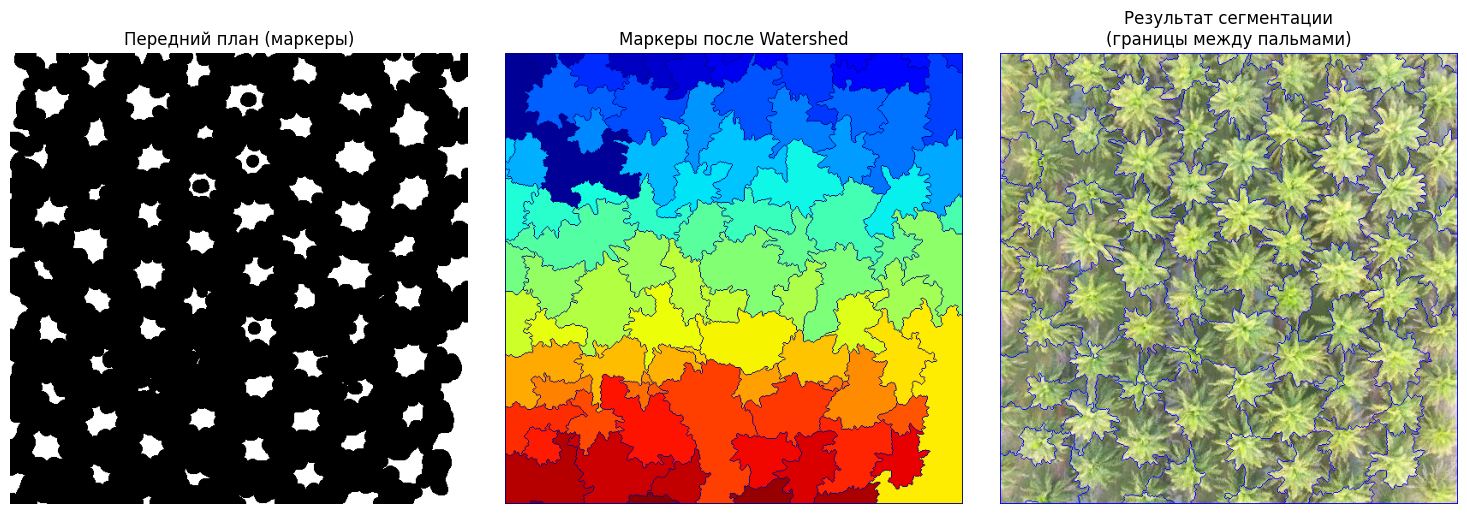

In [9]:
# Определение переднего плана
print("🔹 ОПРЕДЕЛЕНИЕ ПЕРЕДНЕГО ПЛАНА")
ret, sure_fg = cv2.threshold(dist, 0.2 * dist.max(), 255, cv2.THRESH_BINARY)

# Подготовка маркеров
sure_fg = sure_fg.astype(np.uint8)
ret, markers = cv2.connectedComponents(sure_fg)

# Применение watershed
print("🔹 ПРИМЕНЕНИЕ ALGORITHMA WATERSHED")
markers = cv2.watershed(image_palm, markers)

# Помечаем границы красным цветом
image_result = image_palm.copy()
image_result[markers == -1] = [255, 0, 0]  # Красный цвет для границ

# Визуализация результатов
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sure_fg, cmap='gray')
plt.title('Передний план (маркеры)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(markers, cmap='jet')
plt.title('Маркеры после Watershed')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(image_result, cv2.COLOR_BGR2RGB))
plt.title('Результат сегментации\n(границы между пальмами)')
plt.axis('off')

plt.tight_layout()
plt.show()

## 9. 📊 ПОДСЧЕТ РЕЗУЛЬТАТОВ

✅ Уникальных меток: 98
🎯 Количество пальм: 96


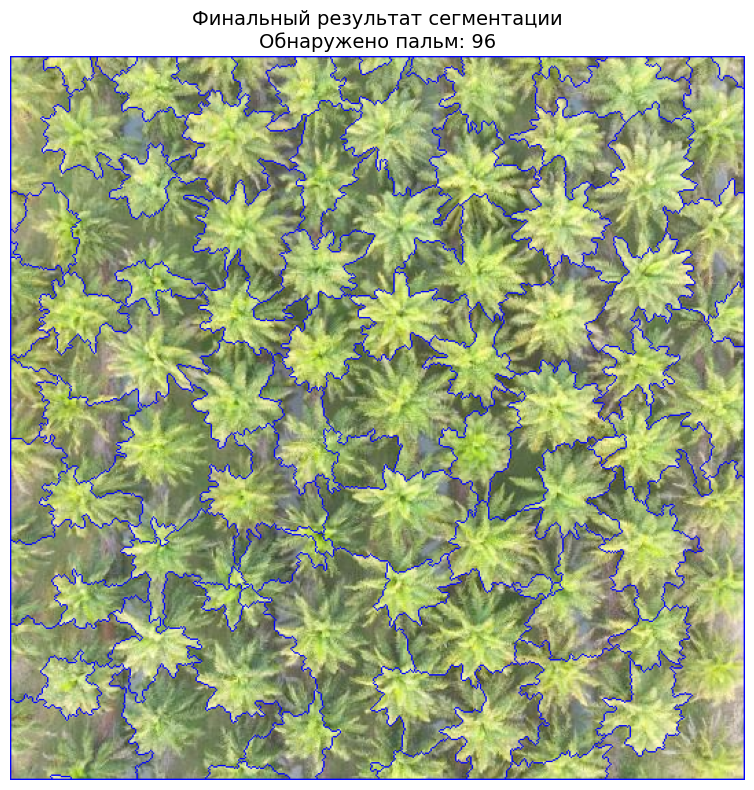

In [10]:
# Подсчет количества пальм
num_palms = len(np.unique(markers)) - 2  # -1 для фона, -1 для границ

print(f"✅ Уникальных меток: {len(np.unique(markers))}")
print(f"🎯 Количество пальм: {num_palms}")

# Итоговая визуализация
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image_result, cv2.COLOR_BGR2RGB))
plt.title(f'Финальный результат сегментации\nОбнаружено пальм: {num_palms}', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()